# Fitting a GMM on the Channel Features.

## Libraries.

In [1]:
from itertools import chain

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import norm
from scipy import special
import torch
from tqdm import tqdm

from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.sym import GaussianMixtureModel

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


## Data.

### Reading the data.

In [2]:
PATH = "../../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying tranformation to the data.

In [3]:
cofactor = 100
key_arcsin = f"X_arcsinh_cof{cofactor}" 
adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_arcsinh_cof100'

### Initializing DataManager and DataLoader.

In [4]:
# data manager
datamanager = DataManager(
    adata,
    sample_rep=key_arcsin
)
data = datamanager.get_data()

BATCH_SIZE = 2048
dataloader = SequentialDataLoader(
    data,
    batch_size=BATCH_SIZE,
)


## Defining GMM.

### Defining function for computing the likelihood of a component.

In [5]:
def compute_gaussian_likelihood(
    samples,
    mean,
    cov,
    homoskedastic=False,
):
    # sanity check on shapes
    assert samples.ndim == 2
    assert mean.ndim == 1
    assert cov.ndim == 2

    # retrieving dimensions
    B, D = samples.shape

    assert D == mean.shape[0]
    if homoskedastic:
        assert cov.shape[0] == 1
    else:
        assert cov.shape[0] == D

    Icov = torch.linalg.inv(cov)
    # computing likelihood
    # idx = torch.arange(B)
    # potential = (-(samples-mean)@(Icov))@(samples-mean).T
    # # print(potential.shape)
    # potential = torch.exp(potential[idx, idx])
    diff = samples - mean
    mahalanobis = torch.einsum('bi,ij,bj->b', diff, Icov, diff)
    potential = torch.exp(-0.5 * mahalanobis)
    norm_factor = (torch.sqrt((2*np.pi**D)*torch.det(cov)))
    # norm_factor = (torch.sqrt(2*(np.pi**D)*cov[torch.arange(D), torch.arange(D)].prod()))
    return potential/norm_factor

mean = torch.zeros((2,))
cov = torch.eye(2)
samples = torch.randn((52, 2))
compute_gaussian_likelihood(samples, mean, cov)


tensor([0.1929, 0.2159, 0.0505, 0.0209, 0.0193, 0.0806, 0.1973, 0.1600, 0.1277,
        0.0276, 0.1991, 0.0419, 0.1746, 0.0583, 0.0897, 0.0747, 0.1906, 0.1579,
        0.0227, 0.0616, 0.1522, 0.2053, 0.1925, 0.1853, 0.2044, 0.0492, 0.1764,
        0.0873, 0.1157, 0.0850, 0.0745, 0.0737, 0.1767, 0.1530, 0.1908, 0.1065,
        0.1211, 0.1677, 0.1671, 0.1926, 0.2237, 0.0173, 0.0455, 0.2216, 0.1268,
        0.0890, 0.0772, 0.1125, 0.0225, 0.1971, 0.2248, 0.1498])

In [6]:
import torch
import numpy as np
import torch.nn.functional as F

def compute_log_gaussian_likelihood(samples, mean, cov):
    """
    Numerically stable log-likelihood computation for a multivariate Gaussian.
    """
    B, D = samples.shape
    diff = samples - mean  # (B, D)
    
    Icov = torch.linalg.inv(cov)  # (D, D)
    mahalanobis = torch.einsum('bi,ij,bj->b', diff, Icov, diff)  # (B,)
    
    log_det = torch.logdet(cov)
    log_norm = -0.5 * (D * np.log(2 * np.pi) + log_det)
    
    return log_norm - 0.5 * mahalanobis  # (B,)


### Defining function for performing E-step.

In [7]:
def e_step(
    samples,
    weight_logits,
    means,
    covs,
    homoskedastic=False,
    use_softmax=False,
):
    
    # sanity check on shapes
    assert samples.ndim == 2
    assert weight_logits.ndim == 1
    assert means.ndim == 2
    assert covs.ndim == 3
    
    # retrieving dimensions
    B, D = samples.shape
    K, D = means.shape

    assert K == covs.shape[0]
    assert K == weight_logits.shape[0]
    if homoskedastic:
        assert covs.shape[1] == 1
    else:
        assert covs.shape[1] == D

    if use_softmax:
        weights_probs = torch.nn.functional.softmax(weight_logits, dim=0)
    else: 
        weights_probs = weight_logits
    lls = torch.zeros(B, K)
    for comp in range(K):
        lls[:, comp] = compute_gaussian_likelihood(samples, means[comp], covs[comp], homoskedastic=homoskedastic)
    den = lls @ weights_probs
    return lls/den.unsqueeze(1)

B = 52
D = 2
K = 5
mean = torch.zeros((K, D,))
cov = torch.eye(D).unsqueeze(0).repeat(K, 1, 1)
w = torch.ones((K,))/K
samples = torch.randn((B, D))
R = e_step(samples, w, mean, cov)
assert R.shape == (B, K)


### Defining function for performing the M-step.

In [8]:
def em_step(
    samples,
    weight_logits,
    means,
    covs,
    homoskedastic=False,
    use_softmax=False,
):    
    # retrieving dimensions
    B, D = samples.shape
    K, D = means.shape

    # e step
    R = e_step(samples, weight_logits, means, covs, homoskedastic=homoskedastic, use_softmax=use_softmax)
    
    # updating weights
    weights = R.sum(0)/B
    
    # updating mean
    means = (R.T @ samples)/(B*weights.unsqueeze(1))

    means_ = means.unsqueeze(1).repeat(1, B, 1)
    samples_ = samples.unsqueeze(0).repeat(K, 1, 1)

    scale = torch.bmm((samples_ - means_).permute(0, 2, 1), ((samples_ - means_)))

    # updating covs
    # covs = R.unsqueeze(-1).unsqueeze(-1).repeat(1, 1, D, D) * scale.unsqueeze(0).repeat(B, 1, 1, 1)
    # covs = covs.sum(0) /B*weights.unsqueeze(-1).unsqueeze(-1)
    covs = torch.zeros(K, D, D)
    for k in range(K):
        diff = samples - means[k]
        weighted_diff = R[:, k].unsqueeze(1) * diff
        covs[k] = (weighted_diff.T @ diff) / R[:, k].sum()

    return weights, means, covs


B = 52
D = 2
K = 5
mean = torch.zeros((K, D,))
cov = torch.eye(D).unsqueeze(0).repeat(K, 1, 1)
w = torch.ones((K,))/K
samples = torch.randn((B, D))
w, means, covs = em_step(samples, w, mean, cov)
assert w.shape == (5,)
assert means.shape == (5, 2)
assert covs.shape == (5, 2, 2)


In [9]:
def e_step(
    samples,
    weight_logits,
    means,
    covs,
    homoskedastic=False,
    use_softmax=False,
):
    assert samples.ndim == 2
    assert weight_logits.ndim == 1
    assert means.ndim == 2
    assert covs.ndim == 3

    B, D = samples.shape
    K, D = means.shape

    assert K == covs.shape[0]
    assert K == weight_logits.shape[0]

    if use_softmax:
        log_weights = F.log_softmax(weight_logits, dim=0)  # (K,)
    else:
        log_weights = torch.log(weight_logits + 1e-9)  # Add small value to avoid log(0)

    log_lls = torch.zeros(B, K)
    for k in range(K):
        log_lls[:, k] = compute_log_gaussian_likelihood(samples, means[k], covs[k]) + log_weights[k]

    # Use log-sum-exp trick
    log_den = torch.logsumexp(log_lls, dim=1, keepdim=True)  # (B, 1)
    log_resp = log_lls - log_den  # (B, K)

    responsibilities = torch.exp(log_resp)  # Convert back to probabilities
    return responsibilities


### Running EM algorithm.

In [10]:
def run_em(
    dataloader,
    d,
    n_comps,
    n_steps,
    homoskedastic=False,
    use_softmax=False,
):
    # history
    w_history = torch.zeros(n_steps + 1, n_comps,)
    mean_history = torch.zeros(n_steps + 1, n_comps, d)
    cov_history = torch.zeros(n_steps + 1, n_comps, d, d)

    # initializing weights
    w = torch.ones((n_comps,))/n_comps
    mean = torch.randn((n_comps, d)) 
    cov = torch.eye(d).repeat(n_comps, 1, 1)

    w_history[0] = w
    mean_history[0] = mean 
    cov_history[0] = cov
    prog_bar = tqdm(range(n_steps))

    for step in range(n_steps):
        samples = dataloader.sample()["state_data"].cpu()
        w, mean, cov = em_step(
            samples,
            w,
            mean,
            cov,
            homoskedastic=homoskedastic,
            use_softmax=use_softmax,    
        )
        w_history[step + 1] = w
        mean_history[step + 1] = mean
        cov_history[step + 1] = cov
        prog_bar.update()
    return w_history, mean_history, cov_history

# settings
DIM = adata.X.shape[1]
N_COMPS = 2
N_STEPS = 10_000

w_history, mean_history, cov_history = run_em(
    dataloader,
    DIM,
    N_COMPS,
    N_STEPS
)


100%|██████████| 10000/10000 [00:25<00:00, 399.74it/s]


### Visualizing the results.

In [11]:
weights = w_history[-1]
means = mean_history[-1]
covs = cov_history[-1]  # shape: (n_components, n_dimensions)

assert weights.shape == (N_COMPS,), weights.shape
assert means.shape == (N_COMPS, DIM), means.shape
assert covs.shape == (N_COMPS, DIM, DIM), covs.shape


### Bar plot of the weights.

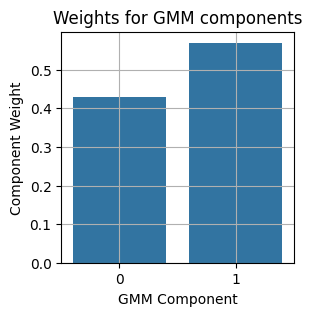

In [12]:
plt.figure()
sns.barplot(x=np.arange(N_COMPS), y=weights)
plt.title("Weights for GMM components")
plt.xlabel("GMM Component")
plt.ylabel("Component Weight")
plt.grid(True)
plt.show()


### Scatter plot of the components mean.


Text(0, 0.5, 'Mean GMM comp 1')

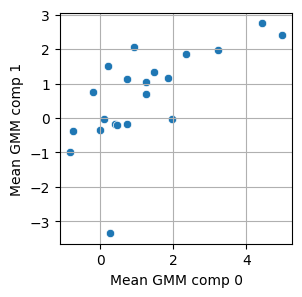

In [13]:
mean0 = means[0]
mean1 = means[1]
sns.scatterplot(x=mean0,y=mean1)
plt.grid(True)
plt.xlabel("Mean GMM comp 0")
plt.ylabel("Mean GMM comp 1")


### Heatmap of the estimated covariances

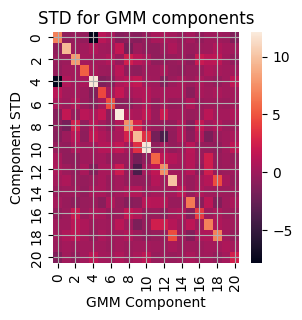

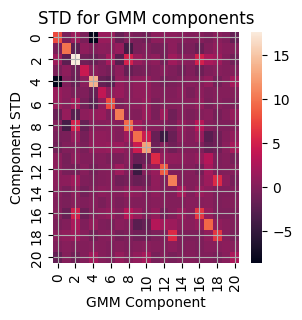

In [15]:
for comp in range(N_COMPS):
    plt.figure()
    sns.heatmap(covs[comp])
    plt.title("STD for GMM components")
    plt.xlabel("GMM Component")
    plt.ylabel("Component STD")
    plt.grid(True)
plt.show()


### Plotting Marginals.

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


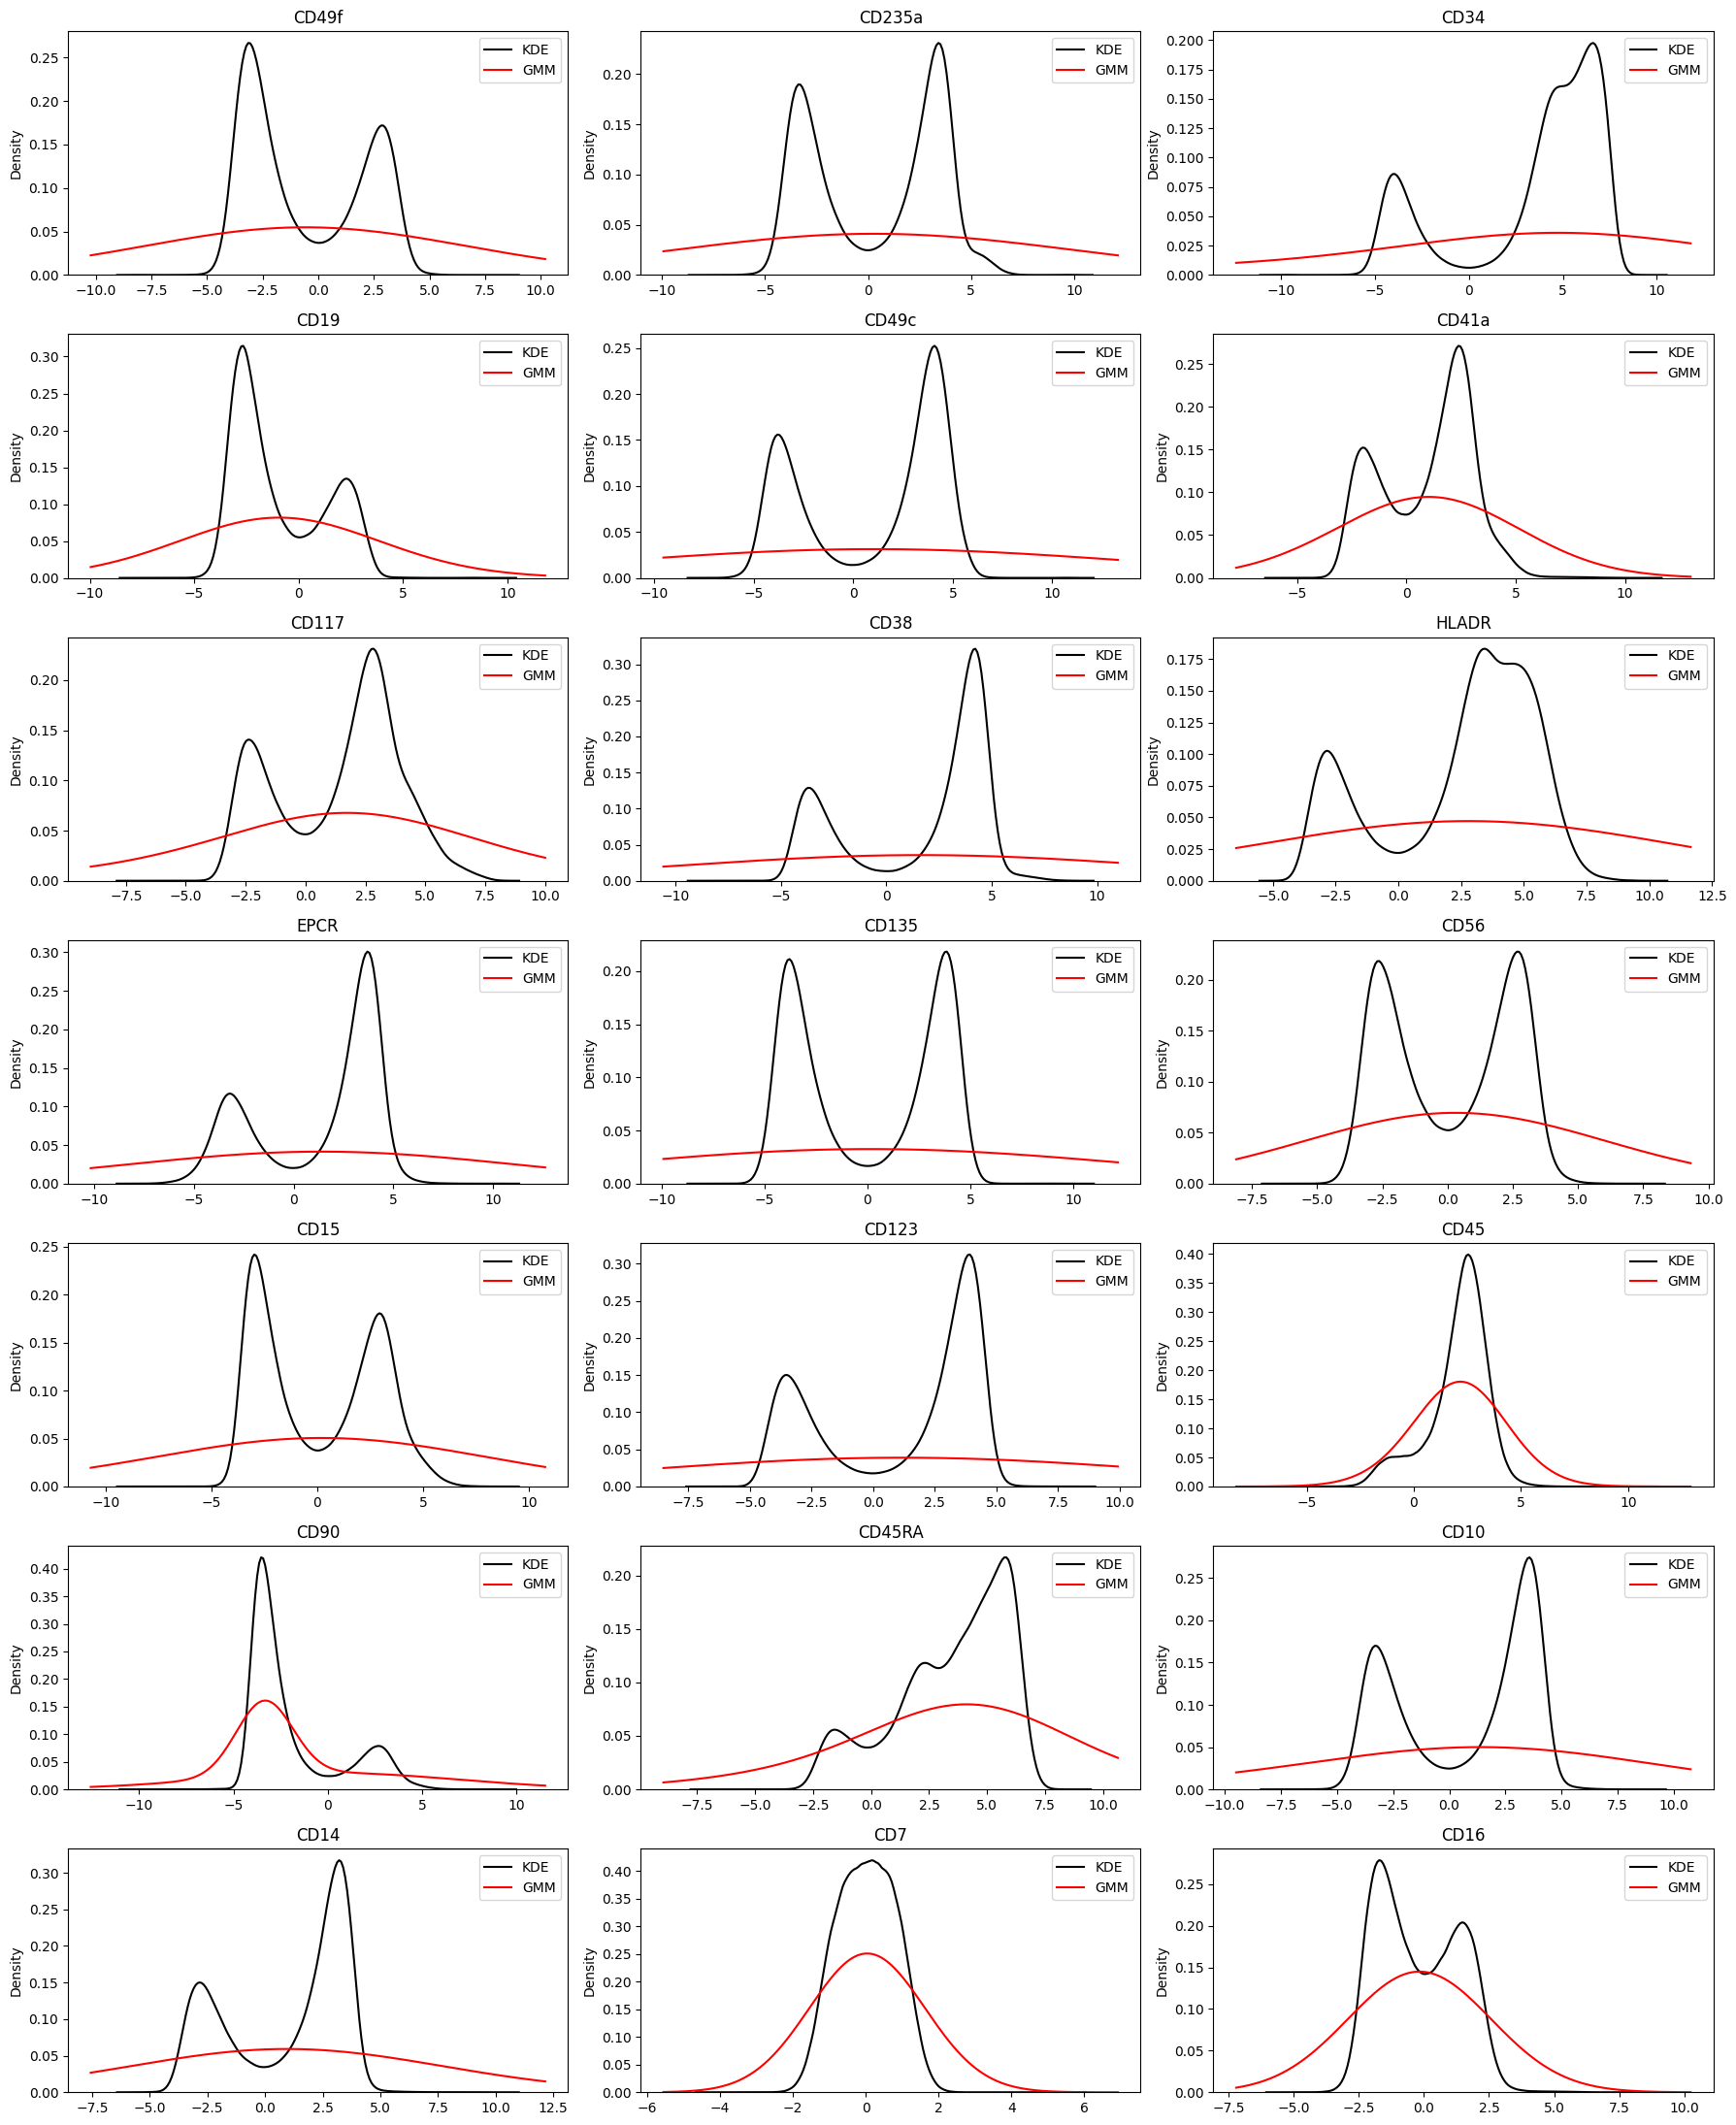

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import special  # for softmax and softplus


# Assume you have these:
# - weights: tensor of shape (K,)
# - means: tensor of shape (K, D)
# - covs: tensor of shape (K, D) or (K,) if homoskedastic
# - data: numpy array of shape (N, D)
# - int2antibody: mapping dim index → antibody name
if 1 == 0:
    sc.pp.subsample(adata, 0.01)
data = adata.obsm[key_arcsin]

int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

# Convert tensors to numpy
if isinstance(weights, torch.Tensor):
    weights = weights.squeeze().detach().cpu().numpy()    # (K,)
if isinstance(means, torch.Tensor):
    means = means.detach().cpu().numpy()                  # (K, D)
if isinstance(covs, torch.Tensor):
    covs = covs.squeeze().detach().cpu().numpy()          # (K, D) or (K,) if homoskedastic

# Apply softmax and softplus to get valid GMM params
weights = special.softmax(weights)                    # (K,)
covs = special.softplus(covs)                         # (K, D) or (K,)

dims = means.shape[1]
K = weights.shape[0]

# Prepare figure
fig, axs = plt.subplots(7, 3, figsize=(18, 22))
axs = axs.flatten()

for dim in range(dims):
    print(dim)
    ax = axs[dim]

    # Grid for plotting
    data_dim = data[:, dim]
    data_min, data_max = data_dim.min(), data_dim.max()
    padding = 0.1 * (data_max - data_min)
    x_grid = np.linspace(data_min - padding, data_max + padding, 200)

    # KDE from real data
    sns.kdeplot(data_dim, ax=ax, label='KDE', color='black')

    proj = np.zeros((dims, ))
    proj[dim] = 1
    sigma = covs@proj
    # GMM marginal density over this dimension
    gmm_density = np.zeros_like(x_grid)
    for k in range(K):
        mu = means[k, dim]
        proj = np.zeros(dims)
        gmm_density += weights[k] * norm.pdf(x_grid, loc=mu, scale=sigma[k, dim])

    ax.plot(x_grid, gmm_density, label='GMM', color='red')
    ax.set_title(int2antibody[dim] if isinstance(int2antibody, dict) else f'Dim {dim}')
    ax.legend()

# Turn off unused axes
for i in range(dims, len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.show()
